In [59]:
# TODO 1: Dùng pandas đọc file dữ liệu nháp.
#
# TODO 2: Chạy các lệnh cơ bản như df.head(), df.info(), df.describe() để xem qua các cột dữ liệu.
#
# TODO 3: Dùng matplotlib hoặc seaborn vẽ thử 1-2 biểu đồ cơ bản (ví dụ: Biểu đồ cột thể hiện doanh thu theo chi nhánh).


Import thư viện pandas, seaborn, matplotlib

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

Dùng thư viện pandas để đọc file

In [61]:
path='../data/raw/supermarket_data_sales.csv'
df=pd.read_csv(path)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Xem 5 dòng đầu tiên của dữ liệu:

In [62]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,CN Quận 1,TP. Hồ Chí Minh,Thành viên,Nữ,Sức khoẻ và làm đẹp,373000.00,7,131000.00,2745000.00,2025-01-05,1:08:00 PM,Ví điện tử (Momo/Zalopay),2614000.00,4.76,131000.00,9.10
1,226-31-3081,CN Hải Châu,Đà Nẵng,Khách thường,Nữ,Phụ kiện điện tử,76000.00,5,19000.00,401000.00,2025-03-08,10:29:00 AM,Tiền mặt,382000.00,4.76,19000.00,9.60
2,631-41-3108,CN Quận 1,TP. Hồ Chí Minh,Khách thường,Nữ,Nhà cửa và đời sống,232000.00,7,81000.00,1703000.00,2025-03-03,1:23:00 PM,Thẻ ngân hàng,1622000.00,4.76,81000.00,7.40
3,123-19-1176,CN Quận 1,TP. Hồ Chí Minh,Thành viên,Nữ,Sức khoẻ và làm đẹp,291000.00,8,116000.00,2445000.00,2025-01-27,8:33:00 PM,Ví điện tử (Momo/Zalopay),2329000.00,4.76,116000.00,8.40
4,373-73-7910,CN Quận 1,TP. Hồ Chí Minh,Thành viên,Nữ,Thể thao và du lịch,432000.00,7,151000.00,3172000.00,2025-02-08,10:37:00 AM,Ví điện tử (Momo/Zalopay),3021000.00,4.76,151000.00,5.30


Xem thông tin cấu trúc (kiểu dữ liệu, số dòng non-null, dung lượng)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

Xem thống kê mô tả (Trung bình, lớn nhất, nhỏ nhất... của các cột số)

In [64]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,278361.00,5.51,76911.00,1614840.00,1537950.00,4.76,76911.00,6.97
std,132473.58,2.92,58545.48,1229425.02,1170889.45,0.00,58545.48,1.72
min,50000.00,1.00,3000.00,53000.00,51000.00,4.76,3000.00,4.00
25%,164000.00,3.00,29750.00,622000.00,592750.00,4.76,29750.00,5.50
50%,276000.00,5.00,60000.00,1269000.00,1209000.00,4.76,60000.00,7.00
75%,390000.00,8.00,112000.00,2356750.00,2244500.00,4.76,112000.00,8.50
max,500000.00,10.00,248000.00,5213000.00,4965000.00,4.76,248000.00,10.00


Vẽ biểu đồ doanh thu theo chi nhánh

/var/folders/3k/n2cz5sh16_jcr3jy680805b40000gn/T/ipykernel_42886/2411623962.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=doanh_thu_theo_chi_nhanh, x='Branch', y='Sales', palette='viridis', ax=ax)


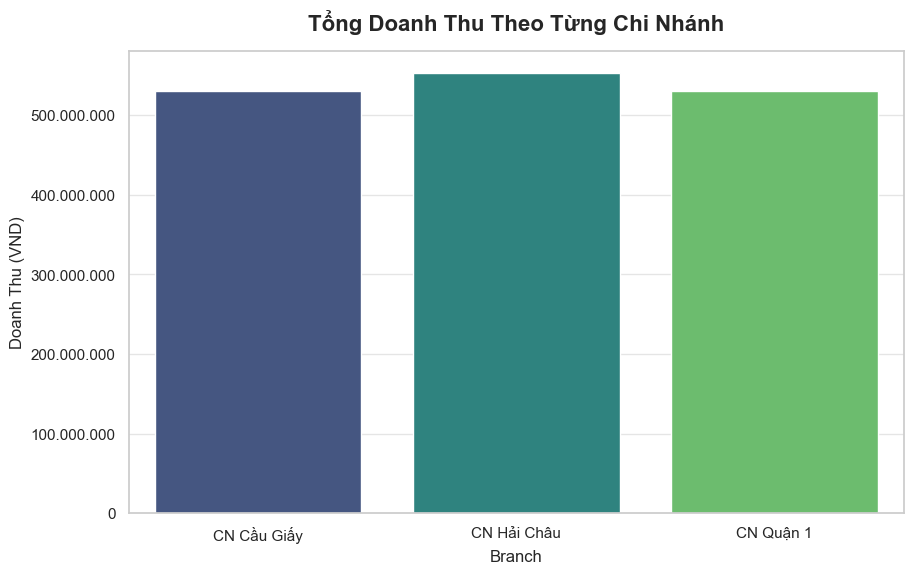

In [68]:
doanh_thu_theo_chi_nhanh=df.groupby('Branch')['Sales'].sum().reset_index()

fig, ax = plt.subplots() # Tạo thêm biến ax để cấu hình trục số
sns.barplot(data=doanh_thu_theo_chi_nhanh, x='Branch', y='Sales', palette='viridis', ax=ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.')))
plt.title('Tổng Doanh Thu Theo Từng Chi Nhánh', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Chi Nhánh', fontsize=12)
plt.ylabel('Doanh Thu (VND)', fontsize=12)
plt.show()
